### Задание №1

1. Нарисуйте невыпуклый многоугольник, изображенный на рисунке, который дальше
будет условно именоваться «самолетом». Координаты его вершин даны в таблице 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets
from matplotlib.patches import Circle
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

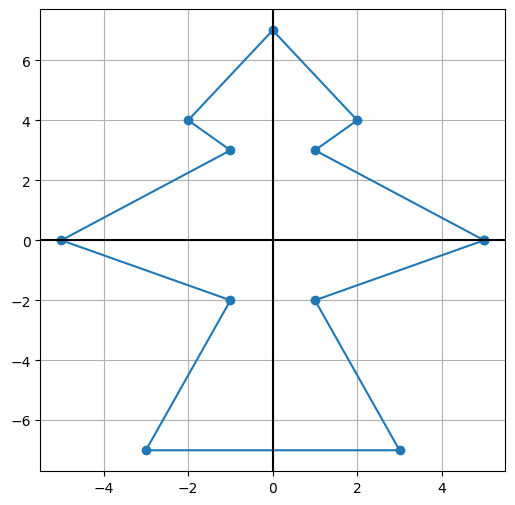

In [5]:
x = [5,1,2,0,-2,-1,-5,-1,-3,3,1,5]
y = [0,3,4,7,4,3,0,-2,-7,-7,-2,0]
plt.figure(figsize=(6,6))
plt.plot(x, y, marker='o')
plt.grid(True)
plt.axhline(0,color='black')
plt.axvline(0,color='black')
plt.show()

2. С помощью матрицы для двумерных вращений
𝑅(𝜃) = (
cos 𝜃
sin 𝜃
− sin 𝜃
cos 𝜃
)
поверните самолет на любой произвольный угол вокруг начала координат. Для этого
создайте ползунок, который будет вращать многоугольник против часовой стрелки с
шагом 1

In [6]:
def plot_figure(angle_input):
    #plt.figure(figsize=(6,6))
    fig, ax = plt.subplots(figsize=(6,6))
    x = np.array([5,1,2,0,-2,-1,-5,-1,-3,3,1,5])
    y = np.array([0,3,4,7,4,3,0,-2,-7,-7,-2,0])
    theta=np.radians(angle_input)
    rotation_matrix = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    points = np.array([x,y])
    rotated_points = rotation_matrix @ points
    x_rotated = rotated_points[0, :] #первая строка результата
    y_rotated = rotated_points[1, :]
    ax.set_xlim(-10, 10) # сеттер(устанавливает)
    ax.set_ylim(-10, 10)
    ax.set_aspect('equal', adjustable='box') #единица по X равна единице по Y
    plt.plot(x_rotated, y_rotated, marker='o')
    plt.grid(True)
    plt.axhline(0,color='black')
    plt.axvline(0,color='black')
    plt.show()
interact(plot_figure, angle_input=widgets.IntSlider(min=0, max=360, step=1))

interactive(children=(IntSlider(value=0, description='angle_input', max=360), Output()), _dom_classes=('widget…

<function __main__.plot_figure(angle_input)>

3. Реализуйте теперь поворот многоугольника вокруг произвольной точки на плоскости.
Точку, вокруг которой делается поворот нужно отобразить на рисунке. Создайте два
ползунка, один из которых регулирует угол поворота, а два других задают координаты
центра поворота.

In [7]:
def plot_figure(angle_input, center_x, center_y):
    fig, ax = plt.subplots(figsize=(6,6))
    x = np.array([5,1,2,0,-2,-1,-5,-1,-3,3,1,5])
    y = np.array([0,3,4,7,4,3,0,-2,-7,-7,-2,0])
    theta = np.radians(angle_input)
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    points = np.array([x - center_x, y - center_y])
    rotated_points = rotation_matrix @ points
    x_rotated = rotated_points[0, :] + center_x
    y_rotated = rotated_points[1, :] + center_y
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect('equal')
    ax.plot(x_rotated, y_rotated, marker='o')
    ax.plot(center_x, center_y,  'ro', markersize=15)
    ax.grid(True)
    ax.axhline(0, color='black')
    ax.axvline(0, color='black')
    plt.show()
interact(plot_figure, angle_input=widgets.IntSlider(min=0, max=360, step=1),center_x=widgets.FloatSlider(min=-8, max=8, step=0.5),center_y=widgets.FloatSlider(min=-8, max=8, step=0.5))

interactive(children=(IntSlider(value=0, description='angle_input', max=360), FloatSlider(value=0.0, descripti…

<function __main__.plot_figure(angle_input, center_x, center_y)>

4. Реализуйте трансляцию на произвольный вектор 𝐭. Задавайте вектор 𝐭 с помощью двух
ползунков: один ползунок регулирует угол наклона вектора к оси 𝑂𝑥 (полярный угол),
а второй ползунок регулирует длину вектора.

In [11]:
def plot_figure(angle_input, vector_angle, vector_length):
    fig, ax = plt.subplots(figsize=(6,6))
    x = np.array([5,1,2,0,-2,-1,-5,-1,-3,3,1,5])
    y = np.array([0,3,4,7,4,3,0,-2,-7,-7,-2,0])
    theta_vector = np.radians(vector_angle)
    tx = vector_length * np.cos(theta_vector)
    ty = vector_length * np.sin(theta_vector)
    x_translated = x + tx
    y_translated = y + ty
    theta = np.radians(angle_input)
    rotation_matrix = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    points = np.array([x_translated, y_translated])
    rotated_points = rotation_matrix @ points
    x_rotated = rotated_points[0, :]
    y_rotated = rotated_points[1, :]
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect('equal', adjustable='box')
    plt.plot(x_rotated, y_rotated, marker='o')
    ax.arrow(0, 0, tx, ty, head_width=0.3, head_length=0.5, fc='red', ec='red')
    plt.grid(True)
    plt.axhline(0,color='black')
    plt.axvline(0,color='black')
    plt.show()
interact(plot_figure, angle_input=widgets.IntSlider(min=0, max=360, step=1),vector_angle=widgets.IntSlider(min=0, max=360, step=1),vector_length=widgets.FloatSlider(min=0, max=5, step=0.5, value=2))

interactive(children=(IntSlider(value=0, description='angle_input', max=360), IntSlider(value=0, description='…

<function __main__.plot_figure(angle_input, vector_angle, vector_length)>

5. Примените к самолету сразу два преобразования: трансляцию на вектор 𝐭 = (
10
5
) и
поворот на угол 60
°
 вокруг центра масс. Результат такого преобразования показан на
рисунке 6, а координаты вершин с точностью до 4 знака приведены в таблице 2. Используйте таблицу для проверки корректности работы программы, а также визуализируйте
результат.


0: (12.7362, 9.4665)
1: (8.1381, 7.5024)
2: (7.7721, 8.8684)
3: (4.1740, 8.6364)
4: (5.7721, 5.4043)
5: (7.1381, 5.7703)
6: (7.7362, 0.8062)
7: (11.4682, 3.2703)
8: (14.7984, -0.9617)
9: (17.7984, 4.2344)
10: (12.4682, 5.0024)
11: (12.7362, 9.4665)


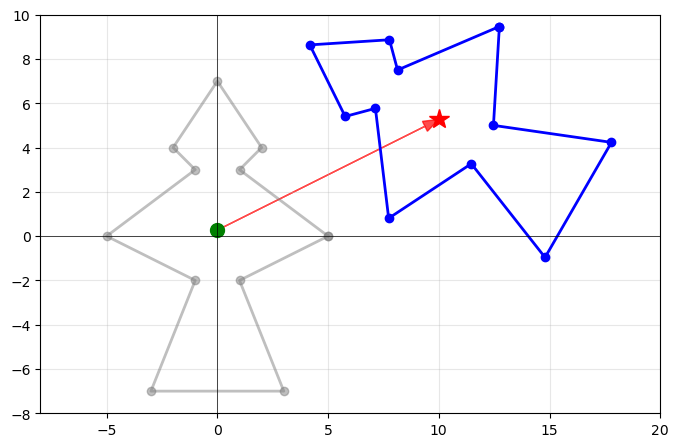

In [12]:
x1 = np.array([5, 1, 2, 0, -2, -1, -5, -1, -3, 3, 1])
y1 = np.array([0, 3, 4, 7, 4, 3, 0, -2, -7, -7, -2])
x = np.array([5, 1, 2, 0, -2, -1, -5, -1, -3, 3, 1, 5])
y = np.array([0, 3, 4, 7, 4, 3, 0, -2, -7, -7, -2, 0])
cx = np.mean(x1) #центр
cy = np.mean(y1)
tx = 10
ty = 5
angle = 60
theta = np.radians(angle)
cos_t = np.cos(theta)
sin_t = np.sin(theta)
x_final = cx + (x - cx) * cos_t - (y - cy) * sin_t + tx
y_final = cy + (x - cx) * sin_t + (y - cy) * cos_t + ty
for i, (xf, yf) in enumerate(zip(x_final, y_final)):
    print(f"{i}: ({xf:.4f}, {yf:.4f})")
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-8, 20)
ax.set_ylim(-8, 10)
ax.set_aspect('equal', adjustable='box')
ax.plot(x, y, 'gray', marker='o', alpha=0.5, linewidth=2)
ax.plot(x_final, y_final, 'blue', marker='o', linewidth=2)
ax.plot(cx, cy, 'go', markersize=10)
ax.plot(cx + tx, cy + ty, 'r*', markersize=15)
ax.arrow(cx, cy, tx, ty, head_width=0.5, head_length=0.7, fc='red', ec='red', alpha=0.7, length_includes_head=True)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
plt.show()

### Задание №2

1. Продолжим преобразования самолета. В данном задании будем отражать лежащий на
боку самолет, который изображен на рисунке 7 и координаты которого приведены в
таблице 3. Как получить эти координаты из таблицы 1?

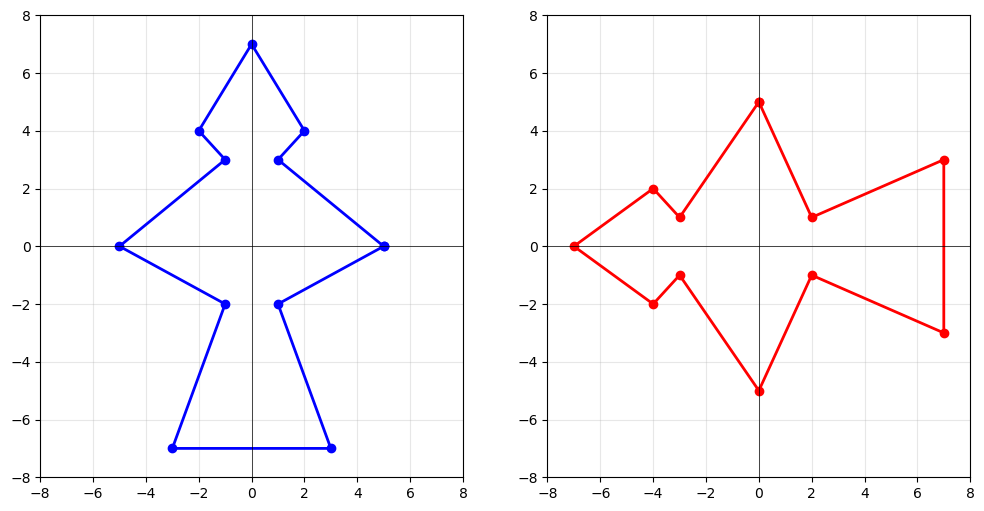

In [18]:
x = np.array([5, 1, 2, 0, -2, -1, -5, -1, -3, 3, 1, 5])
y = np.array([0, 3, 4, 7, 4, 3, 0, -2, -7, -7, -2, 0])
x_new = -y #x = x·cos - y·sin
y_new = x  #y = x·sin + y·cos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, y, 'bo-', linewidth=2, markersize=6)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.5)
ax1.set_xlim(-8, 8)
ax1.set_ylim(-8, 8)

ax2.plot(x_new, y_new, 'ro-', linewidth=2, markersize=6)
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=0.5)
ax2.set_xlim(-8, 8)
ax2.set_ylim(-8, 8)
plt.show()

2. С помощью матрицы для двумерных отражений 𝑅𝑓(𝜃) и вектора трансляции 𝐭 таких,
что:
𝑅𝑓(𝜃) = (
cos 𝜃
sin 𝜃
sin 𝜃
− cos 𝜃
) 𝐭 = (
𝑡𝑥
𝑡𝑦
)
отразите самолет относительно произвольной прямой 𝑙1
. Объясните геометрический смысл параметра 𝜃 матрицы 𝑅𝑓(𝜃), как он связан с прямой 𝑙1?

Параметр θ в матрице R_f(θ) определяет угол наклона прямой L1, относительно которой происходит отражение.

In [28]:
x = np.array([5, 1, 2, 0, -2, -1, -5, -1, -3, 3, 1, 5])
y = np.array([0, 3, 4, 7, 4, 3, 0, -2, -7, -7, -2, 0])
def plot_reflection(theta_line):
    theta_rad = np.radians(theta_line)
    cos_t = np.cos(theta_rad)
    sin_t = np.sin(theta_rad)
    R = np.array([[cos_t, sin_t], [sin_t, -cos_t]])
    points = np.array([x, y])
    reflected = R @ points
    x_ref = reflected[0, :]
    y_ref = reflected[1, :]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(x, y, 'blue', linewidth=2, marker='o', markersize=4, label='Исходный')
    ax.plot(x_ref, y_ref, 'red', linewidth=2, marker='o', markersize=4, label='Отражённый')
    angle_line = theta_line / 2  
    line_rad = np.radians(angle_line)
    ax.plot([-8, 8], [-8 * np.tan(line_rad), 8 * np.tan(line_rad)], 'green', linestyle='--', linewidth=2, label=f'l1 ({angle_line}°)')
    ax.set_xlim(-8, 8)
    ax.set_ylim(-8, 8)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.axhline(0, color='black')
    ax.axvline(0, color='black')
    ax.legend()
    plt.show()
interact(plot_reflection, theta_line=IntSlider(min=0, max=180, step=5, value=45))

interactive(children=(IntSlider(value=45, description='theta_line', max=180, step=5), Output()), _dom_classes=…

<function __main__.plot_reflection(theta_line)>

3. Создать ползунок, с помощью которого можно будет регулировать угол наклона прямой
𝑙1
 относительно оси 𝑂𝑥. Самолет при этом должен всякий раз отражаться относительно
нового положения прямой. Также можно ввести дополнительный ползунок, который
регулирует координату 𝑥, через которую проходит прямая.


In [30]:
x = np.array([5, 1, 2, 0, -2, -1, -5, -1, -3, 3, 1, 5])
y = np.array([0, 3, 4, 7, 4, 3, 0, -2, -7, -7, -2, 0])
def reflect_line(x, y, theta_deg, x0):
    theta = np.radians(theta_deg)
    R = np.array([[np.cos(theta), np.sin(theta)],[np.sin(theta), -np.cos(theta)]])
    points = np.array([x - x0, y])
    reflected = R @ points
    return reflected[0] + x0, reflected[1]
def plot_figure(theta_line, x_intercept):
    fig, ax = plt.subplots(figsize=(8, 8))
    x_ref, y_ref = reflect_line(x, y, theta_line, x_intercept)
    ax.plot(np.append(x_ref, x_ref[0]),np.append(y_ref, y_ref[0]),'red', linewidth=2, marker='o')
    theta = np.radians(theta_line)
    length = 15
    dx = length * np.cos(theta)
    dy = length * np.sin(theta)
    ax.plot([x_intercept - dx, x_intercept + dx],[-dy, dy],'green', linestyle='--', linewidth=2)

    ax.plot(x, y, 'blue', linewidth=2, marker='o', markersize=4)
    ax.set_xlim(-12, 12)
    ax.set_ylim(-10, 10)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.axhline(0, color='black')
    ax.axvline(0, color='black')
    plt.show()
interact(plot_figure,theta_line=widgets.IntSlider(min=0, max=180, step=5),x_intercept=widgets.FloatSlider(min=-8, max=8, step=0.5))

interactive(children=(IntSlider(value=0, description='theta_line', max=180, step=5), FloatSlider(value=0.0, de…

<function __main__.plot_figure(theta_line, x_intercept)>

4. Добавьте на рисунок вторую прямую 𝑙2
, которую также можно регулировать ползунками. Отразите самолет сначала относительно 𝑙1
, а затем результат отражения относительно 𝑙2
.

In [32]:
x = np.array([5, 1, 2, 0, -2, -1, -5, -1, -3, 3, 1, 5])
y = np.array([0, 3, 4, 7, 4, 3, 0, -2, -7, -7, -2, 0])
def reflect_line(x, y, theta_deg, x0):
    theta = np.radians(theta_deg)
    R = np.array([[np.cos(theta), np.sin(theta)],[np.sin(theta), -np.cos(theta)]])
    points = np.array([x - x0, y])
    reflected = R @ points
    return reflected[0] + x0, reflected[1]

def plot_figure(theta1, x1, theta2, x2):
    fig, ax = plt.subplots(figsize=(8, 8))
    x_ref1, y_ref1 = reflect_line(x, y, theta1, x1)
    x_ref2, y_ref2 = reflect_line(x_ref1, y_ref1, theta2, x2)
    ax.plot(x_ref2, y_ref2, 'red', linewidth=2, marker='o', label='После 2 отражений')
    length = 15
    for theta, x0, color, label in [(theta1, x1, 'green', 'l1'),(theta2, x2, 'purple', 'l2')]:
        t = np.radians(theta)
        dx = length * np.cos(t)
        dy = length * np.sin(t)
        ax.plot([x0 - dx, x0 + dx], [-dy, dy],linestyle='--', color=color, linewidth=2, label=label)
    ax.plot(x, y, 'blue', linewidth=2, marker='o', markersize=4)
    ax.set_xlim(-12, 12)
    ax.set_ylim(-10, 10)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.axhline(0, color='black')
    ax.axvline(0, color='black')
    ax.legend()
    plt.show()
interact(plot_figure,theta1=widgets.IntSlider(min=0, max=180, step=5),x1=widgets.FloatSlider(min=-8, max=8, step=0.5),theta2=widgets.IntSlider(min=0, max=180, step=5),x2=widgets.FloatSlider(min=-8, max=8, step=0.5))

interactive(children=(IntSlider(value=0, description='theta1', max=180, step=5), FloatSlider(value=0.0, descri…

<function __main__.plot_figure(theta1, x1, theta2, x2)>

5. Проверьте корректность работы программы используя рисунок 8 и координаты вершин
из таблиц 4, 5, 6. Как из рисунка геометрическим путем понять, что фигура отражается?

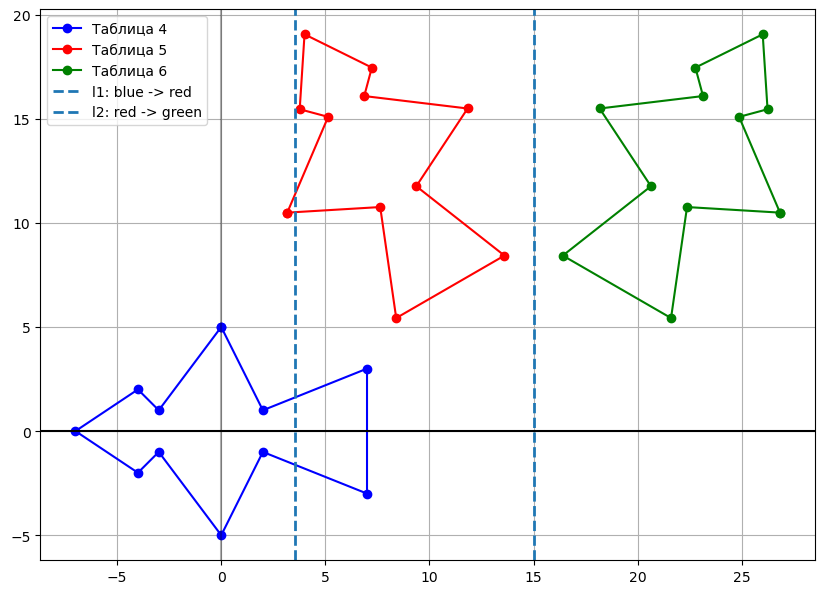

In [33]:
x = np.array([5, 1, 2, 0, -2, -1, -5, -1, -3, 3, 1])
y = np.array([0, 3, 4, 7, 4, 3, 0, -2, -7, -7, -2])
x_side = -y
y_side = x
x_ref1 = np.array([3.1699, 5.134, 3.7679, 4, 7.2321, 6.866,11.8301, 9.366, 13.5981, 8.4019, 7.634])
y_ref1 = np.array([10.4904, 15.0885, 15.4545, 19.0526, 17.4545,16.0885, 15.4904, 11.7583, 8.4282, 5.4282, 10.7583])
x_ref2 = np.array([26.8301, 24.866, 26.2321, 26, 22.7679, 23.134,18.1699, 20.634, 16.4019, 21.5981, 22.366])
y_ref2 = y_ref1.copy()
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(np.append(x_side, x_side[0]), np.append(y_side, y_side[0]),'bo-', label='Таблица 4')
ax.plot(np.append(x_ref1, x_ref1[0]), np.append(y_ref1, y_ref1[0]),'ro-', label='Таблица 5')
ax.plot(np.append(x_ref2, x_ref2[0]), np.append(y_ref2, y_ref2[0]),'go-', label='Таблица 6')
l1 = (np.mean(x_side) + np.mean(x_ref1)) / 2
l2 = (np.mean(x_ref1) + np.mean(x_ref2)) / 2
ax.axvline(l1, linestyle='--', linewidth=2, label='l1: blue -> red')
ax.axvline(l2, linestyle='--', linewidth=2, label='l2: red -> green')
ax.grid(True)
ax.axhline(0, color='black')
ax.axvline(0, color='black', alpha=0.3)
ax.set_aspect('equal')
ax.legend()
plt.show()

- каждая точка и её образ лежат по разные стороны от прямой;
- расстояния до прямой одинаковые;
- сама прямая является серединным перпендикуляром;
- ориентация фигуры меняется на зеркальную.

6. Можно ли первое отражение получить с помощью поворота исходной фигуры? Можно
ли получить вращением второе отражение из исходной фигуры? Ответ обоснуйте геометрически и алгебраически.

Нет, отражение нельзя получить одним только поворотом из исходной фигуры

Геометрически:
- при повороте сохраняется ориентация обхода вершин;
- при отражении ориентация меняется на противоположную.

Алгебраически:
- у матрицы поворота определитель +1;
- у матрицы отражения определитель -1.

Поэтому отражение не является поворотом.

### Задание №3

Повторите задания 1 и 2 с использованием комплексных чисел вместо матриц

In [34]:
P = np.array([5+0j, 1+3j, 2+4j, 0+7j, -2+4j,-1+3j, -5+0j, -1-2j, -3-7j, 3-7j, 1-2j])
def plot_figure(theta_deg):
    theta = np.radians(theta_deg)
    u = np.exp(1j * theta)
    Ps = u * P
    X = np.real(Ps)
    Y = np.imag(Ps)
    plt.figure(figsize=(6,6))
    plt.plot(np.append(X, X[0]), np.append(Y, Y[0]), marker='o')
    plt.grid(True)
    plt.axhline(0, color='black')
    plt.axvline(0, color='black')
    plt.axis('equal')
    plt.show()
interact(plot_figure,theta_deg=widgets.IntSlider(min=0, max=360, step=1))

interactive(children=(IntSlider(value=0, description='theta_deg', max=360), Output()), _dom_classes=('widget-i…

<function __main__.plot_figure(theta_deg)>

In [35]:
def plot_reflection(theta_deg):
    theta = np.radians(theta_deg)
    u = np.exp(1j * theta)
    Ps = u * np.conj(P) #умножается на сопряжение (отражение относительно ox)
    X = np.real(Ps)
    Y = np.imag(Ps)
    plt.figure(figsize=(6,6))
    plt.plot(np.append(X, X[0]), np.append(Y, Y[0]), marker='o')
    plt.grid(True)
    plt.axhline(0, color='black')
    plt.axvline(0, color='black')
    plt.axis('equal')
    plt.show()
interact(plot_reflection,theta_deg=widgets.IntSlider(min=0, max=180, step=1))

interactive(children=(IntSlider(value=0, description='theta_deg', max=180), Output()), _dom_classes=('widget-i…

<function __main__.plot_reflection(theta_deg)>

In [36]:
def plot_rotation_point(theta_deg, center_x, center_y):
    center = center_x + 1j * center_y
    theta = np.radians(theta_deg)
    u = np.exp(1j * theta)
    Ps = u * (P - center) + center
    X = np.real(Ps)
    Y = np.imag(Ps)
    plt.figure(figsize=(6,6))
    plt.plot(np.append(X, X[0]), np.append(Y, Y[0]), marker='o')
    plt.plot(center_x, center_y, 'ro', markersize=10)
    plt.grid(True)
    plt.axhline(0, color='black')
    plt.axvline(0, color='black')
    plt.axis('equal')
    plt.show()
interact(plot_rotation_point,theta_deg=widgets.IntSlider(min=0, max=360, step=1),center_x=widgets.FloatSlider(min=-8, max=8, step=0.5),center_y=widgets.FloatSlider(min=-8, max=8, step=0.5))

interactive(children=(IntSlider(value=0, description='theta_deg', max=360), FloatSlider(value=0.0, description…

<function __main__.plot_rotation_point(theta_deg, center_x, center_y)>

2. В чем, на ваш взгляд, преимущество использования комплексных чисел по сравнению
с двумерными векторами?

1. Формулы короче и проще.
2. Не нужно явно задавать матрицы 2x2.
3. Поворот и отражение записываются одной формулой.
4. Код становится компактнее и легче читается.